In [1]:
!rm -rf /root/.cache/huggingface
!rm -rf /root/.cache/torch

In [2]:
pip install --upgrade nbformat ipython ipykernel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.7/625.7 kB 11.0 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.8/118.8 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.4/107.4 kB 7.5 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
  Attempting uninstall: jupyter-client
    Found existing installation: jupyter_client 7.4.9
    Uninstalling jupyter_client-7.4.9:
      Successfully uninstalled jupyter_client-7.4.9
  Attempting uninstall: ipython
    Found existing installation: ipython 7.34.0
    Uninstalling ipython-7.34.0:
      Successfully uninstalled ipython-7.34.0
  Attempting uninstall: ipykernel
    Found existing installation: ipykernel 6.17.1
    Uninstalling ipykernel-6.17.1:
      Successfully uninstalled ipykernel-6.17.1
ERROR: pip's dependency resolver does not currently take into account all th

In [3]:
!rm -rf /content/whisper-small-gu-lora-old
!rm -rf /content/whisper-old-checkpoint

In [4]:
!pip install datasets >= 2.6.1
!pip install librosa
!pip install evaluate >=0.30
!pip install jiwer

ERROR: Could not find a version that satisfies the requirement 2.6.1 (from versions: none)
ERROR: No matching distribution found for 2.6.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 35.6 MB/s eta 0:00:0000:0100:01


In [5]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN_3")

login(token=hf_token)

In [6]:
# !pip uninstall wandb -y
# !pip install wandb --upgrade

In [4]:
from pathlib import Path
from typing import Any, Dict, List, Optional, Union
import gc, json ,os , random

In [8]:
import wandb

In [1]:
import numpy as np
import torch
import torchaudio
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import soundfile as sf
from collections import Counter

In [10]:
torch.backends.cuda.matmul.allow_tf32 = True

In [11]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [5]:
from dataclasses import dataclass, field

@dataclass
class HParams:

    model_name: str          = "openai/whisper-small"
    language: str            = "Gujarati"
    task: str                = "transcribe"
    target_sr: int           = 16_000
    max_audio_len_sec: float = 30.0
    max_input_length: int    = int(target_sr * max_audio_len_sec)

    lora_r: int              = 32
    lora_alpha: int          = 64
    lora_dropout: float      = 0.05

    lora_target_modules: List[str] = field(default_factory=lambda: [
        "q_proj", "v_proj",
        "k_proj", "out_proj",
        "fc1", "fc2",
    ])
    bias: str                = "none"

    output_dir: str          = "./whisper-small-gu-lora"
    num_train_epochs: int    = 8
    per_device_train_bs: int = 8
    per_device_eval_bs: int  = 8
    gradient_accumulation: int = 2
    learning_rate: float     = 1e-4
    warmup_steps: int        = 300
    weight_decay: float      = 0.01
    max_grad_norm: float      = 1.0
    fp16: bool               = True
    eval_strategy: str       = "epoch"
    save_strategy: str       = "epoch"
    logging_steps: int       = 50
    load_best_model: bool    = True
    metric_for_best: str     = "wer"
    greater_is_better: bool  = False
    generation_max_length: int = 225
    predict_with_generate: bool = True
    early_stopping_patience: int = 4


    dataset_name: str        = "ai4bharat/kathbath"
    dataset_lang: str        = "gujarati"
    val_frac: float          = 0.1
    test_frac: float         = 0.1

    wandb_project: str       = "whisper-kathbath-gujarati"
    wandb_run_name: str      = "whisper-small-lora-gu"

    onnx_dir: str            = "./whisper-small-gu-onnx"


hp = HParams()
print(json.dumps(hp.__dict__, indent=2, default=str))

{
  "model_name": "openai/whisper-small",
  "language": "Gujarati",
  "task": "transcribe",
  "target_sr": 16000,
  "max_audio_len_sec": 30.0,
  "max_input_length": 480000,
  "lora_r": 32,
  "lora_alpha": 64,
  "lora_dropout": 0.05,
  "lora_target_modules": [
    "q_proj",
    "v_proj",
    "k_proj",
    "out_proj",
    "fc1",
    "fc2"
  ],
  "bias": "none",
  "output_dir": "./whisper-small-gu-lora",
  "num_train_epochs": 8,
  "per_device_train_bs": 8,
  "per_device_eval_bs": 8,
  "gradient_accumulation": 2,
  "learning_rate": 0.0001,
  "warmup_steps": 300,
  "weight_decay": 0.01,
  "max_grad_norm": 1.0,
  "fp16": true,
  "eval_strategy": "epoch",
  "save_strategy": "epoch",
  "logging_steps": 50,
  "load_best_model": true,
  "metric_for_best": "wer",
  "greater_is_better": false,
  "generation_max_length": 225,
  "predict_with_generate": true,
  "early_stopping_patience": 4,
  "dataset_name": "ai4bharat/kathbath",
  "dataset_lang": "gujarati",
  "val_frac": 0.1,
  "test_frac": 0.1,
 

In [13]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}  |  GPU: {torch.cuda.get_device_name(0) if DEVICE=='cuda' else 'N/A'}")

Device: cuda  |  GPU: Tesla T4


In [14]:
# !pip install wandb

In [15]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: turingetic_guy (turingetic_guy-iitram-institute-of-infrastructure-techno) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [16]:
run = wandb.init(
    project=hp.wandb_project,
    name=hp.wandb_run_name,
    config=hp.__dict__,
    mode="online"
)

In [ ]:
from datasets import load_dataset, Audio, DatasetDict
import matplotlib.pyplot as plt
from transformers import WhisperFeatureExtractor, WhisperTokenizer, WhisperProcessor, WhisperForConditionalGeneration, Seq2SeqTrainingArguments, Seq2SeqTrainer, EarlyStoppingCallback


feature_extractor = WhisperFeatureExtractor.from_pretrained(hp.model_name)
tokenizer = WhisperTokenizer.from_pretrained( hp.model_name, language=hp.language, task=hp.task,)
processor = WhisperProcessor.from_pretrained( hp.model_name, language=hp.language, task=hp.task,)



print("Feature extractor sampling rate:", feature_extractor.sampling_rate)
print("Tokenizer vocab size           :", tokenizer.vocab_size)
print("Model max length               :", tokenizer.model_max_length)


In [ ]:
raw = load_dataset( hp.dataset_name,  hp.dataset_lang,split="train[:23%]" ,token=True,)
print(raw)

In [19]:
from sklearn.model_selection import train_test_split
from datasets import DatasetDict

splits = raw.train_test_split(test_size=0.2, seed=SEED)
train_ds = splits["train"]
# train_size = int(0.4 * len(raw["train"]))
# train_ds = raw["train"].select(range(train_size))

In [20]:
# val_ds_full = raw["valid"]
val_test_split = splits["test"].train_test_split(test_size=0.5, seed=SEED)
val_ds  = val_test_split["train"]
test_ds = val_test_split["test"]

In [21]:
raw = DatasetDict({
    "train":      train_ds,
    "validation": val_ds,
    "test":       test_ds,
})

print("\nFinal split sizes:")

for k, v in raw.items():
    print(f"  {k:12s}: {len(v):,} samples")


Final split sizes:
  train       : 12,303 samples
  validation  : 1,538 samples
  test        : 1,538 samples


In [22]:
print(raw['train'][0])

{'fname': '844424931471880-1140-f.m4a', 'text': 'પણ કોર્ટે કહ્યુ હતુ કે તમે એક એક વાર પરસ્પર ઉકેલ લાવવા બેસો તો ખરા', 'audio_filepath': <datasets.features._torchcodec.AudioDecoder object at 0x7c586a22e3f0>, 'lang': 'gu', 'duration': 7.848375, 'gender': 'Female', 'speaker_id': 1140}


In [23]:
from datasets import Audio

In [24]:
print(train_ds)
print(val_ds)
print(test_ds)

Dataset({
    features: ['fname', 'text', 'audio_filepath', 'lang', 'duration', 'gender', 'speaker_id'],
    num_rows: 12303
})
Dataset({
    features: ['fname', 'text', 'audio_filepath', 'lang', 'duration', 'gender', 'speaker_id'],
    num_rows: 1538
})
Dataset({
    features: ['fname', 'text', 'audio_filepath', 'lang', 'duration', 'gender', 'speaker_id'],
    num_rows: 1538
})


In [ ]:

def check_sample_rates(dataset, n_samples=500):
    rates = Counter()

    audio_col = next(c for c in dataset.column_names if dataset.features[c].__class__.__name__ == "Audio")
    for ex in dataset.select(range(min(n_samples, len(dataset)))):
        sr = ex[audio_col]["sampling_rate"]
        rates[sr] += 1
    return rates


print("Sample rates in train set:")
sr_counts = check_sample_rates(raw["train"], n_samples=500)

for sr, cnt in sorted(sr_counts.items()):
    print(f"  {sr} Hz  → {cnt} samples")

Sample rates in train set:
  16000 Hz  → 500 samples


In [26]:
def build_vocab(dataset, text_col="sentence", n_samples=None):
    """Build word + character frequency from transcriptions."""
    word_counter = Counter()
    char_counter = Counter()
    subset = dataset if n_samples is None else dataset.select(range(min(n_samples, len(dataset))))
    for ex in subset:
        text = ex.get(text_col, ex.get("text", "")).strip()
        words = text.split()
        word_counter.update(words)
        char_counter.update(list(text.replace(" ", "")))
    return word_counter, char_counter

text_col = "sentence" if "sentence" in raw["train"].column_names else "text"

word_freq, char_freq = build_vocab(raw["train"], text_col=text_col, n_samples=5000)

print(f"Unique words : {len(word_freq):,}")
print(f"Unique chars : {len(char_freq):,}")
print("\nTop-30 words:")
for w, c in word_freq.most_common(30):
    print(f"  {w!r:30s} {c}")
print("\nTop-30 chars:")
for ch, c in char_freq.most_common(30):
    print(f"  {ch!r:10s} {c}")


Unique words : 16,119
Unique chars : 63

Top-30 words:
  'છે'                           2954
  'અને'                          1041
  'આ'                            1026
  'પણ'                           691
  'માટે'                         666
  'કે'                           532
  'એક'                           487
  'પર'                           487
  'જ'                            421
  'તે'                           417
  'કરી'                          413
  'હતી'                          362
  'સાથે'                         353
  'નથી'                          271
  'હતો'                          261
  'કરવામાં'                      243
  'હતા'                          234
  'આવી'                          224
  'તો'                           218
  'આવે'                          174
  'હોય'                          171
  'એ'                            168
  'હતું'                         164
  'જે'                           147
  'દ્વારા'                       146
  'રીતે'         

In [27]:
vocab_path = Path(hp.output_dir)
vocab_path.mkdir(parents=True, exist_ok=True)
with open(vocab_path / "kathbath_gu_word_vocab.json", "w", encoding="utf-8") as f:
    json.dump(dict(word_freq.most_common()), f, ensure_ascii=False, indent=2)
with open(vocab_path / "kathbath_gu_char_vocab.json", "w", encoding="utf-8") as f:
    json.dump(dict(char_freq.most_common()), f, ensure_ascii=False, indent=2)



In [28]:
def plot_frequency(counter, title, top_n=40, fname=None):
    labels, counts = zip(*counter.most_common(top_n))
    fig, ax = plt.subplots(figsize=(14, 5))
    bars = ax.bar(range(len(labels)), counts, color=plt.cm.viridis(np.linspace(0.2, 0.9, len(labels))))
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=75, fontsize=8, ha="right")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylabel("Frequency")
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    plt.tight_layout()
    if fname:
        plt.savefig(fname, dpi=150)
        wandb.log({title: wandb.Image(fname)})
    plt.show()

In [29]:
# run once
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# install Noto Sans Gujarati
import subprocess
subprocess.run(["pip", "install", "-q", "requests"])
subprocess.run([
    "wget", "-q",
    "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansGujarati/NotoSansGujarati-Regular.ttf",
    "-O", "/tmp/NotoSansGujarati-Regular.ttf"
])

fm.fontManager.addfont("/tmp/NotoSansGujarati-Regular.ttf")
plt.rcParams["font.family"] = "Noto Sans Gujarati"
plt.rcParams["axes.unicode_minus"] = False

In [30]:
# plot_frequency(char_freq, "Gujarati Character Frequency (Kathbath)", top_n=50,
#                fname=str(vocab_path / "char_freq.png"))
# plot_frequency(word_freq, "Gujarati Word Frequency (Kathbath)", top_n=40,
#                fname=str(vocab_path / "word_freq.png"))

In [31]:
raw = raw.cast_column("audio", Audio(sampling_rate=hp.target_sr))

In [ ]:
!rm -rf ~/.cache/huggingface/datasets
import gc
gc.collect()
print(" Cache cleared, resampled data still in memory")

✓ Cache cleared, resampled data still in memory


In [33]:
def normalize_text(text: str) -> str:
    """Minimal normalization — keep Gujarati Unicode intact."""
    text = text.strip()
    # Remove double spaces
    import re
    text = re.sub(r"\s+", " ", text)
    return text

In [34]:
# import soundfile as sf
# import torchaudio
# import torchaudio.transforms as T

# AUDIO_COL = "audio_filepath"
# TEXT_COL  = "text"

# resamplers = {}  # cache resampler per sr to avoid recreating

# def prepare_dataset(batch):
#     audio_path = batch[AUDIO_COL]

#     try:
#         waveform, sr = torchaudio.load(audio_path)  # (C, T), int16 or float
#         waveform = waveform.mean(dim=0)              # mono, shape (T,)

#         if sr != 16000:
#             if sr not in resamplers:
#                 resamplers[sr] = T.Resample(sr, 16000)
#             waveform = resamplers[sr](waveform)

#         waveform = waveform.numpy().astype(np.float32)
#     except Exception:
#         return {"input_features": None, "labels": None}

#     if waveform.size == 0:
#         return {"input_features": None, "labels": None}

#     if len(waveform) > hp.max_input_length:
#         waveform = waveform[:hp.max_input_length]

#     min_len = int(0.5 * 16000)
#     if len(waveform) < min_len:
#         waveform = np.pad(waveform, (0, min_len - len(waveform)))

#     input_features = feature_extractor(
#         waveform,
#         sampling_rate=16000,
#         return_tensors="np",
#         padding="max_length",
#         truncation=True,
#     ).input_features[0]

#     del waveform

#     text = normalize_text(batch[TEXT_COL])
#     labels = tokenizer(text).input_ids
#     labels = [t if t != tokenizer.pad_token_id else -100 for t in labels]

#     return {"input_features": input_features, "labels": labels}


# processed = DatasetDict()
# for split_name, split_data in raw.items():
#     mapped = split_data.map(
#         prepare_dataset,
#         remove_columns=split_data.column_names,
#         num_proc=1,
#         batched=False,
#         writer_batch_size=200,
#         desc=f"Processing {split_name}",
#     )
#     processed[split_name] = mapped.filter(
#         lambda x: x["input_features"] is not None,
#         writer_batch_size=200,
#     )
#     gc.collect()
#     print(f"{split_name}: {len(processed[split_name])} samples")

In [35]:
# import soundfile as sf
# from datasets import DatasetDict

# AUDIO_COL = "audio_filepath"
# TEXT_COL  = "text"

# def prepare_dataset(batch):
#     audio_path = batch[AUDIO_COL]

#     try:
#         waveform, sr = librosa.load(audio_path, sr=hp.target_sr, mono=True)
#         waveform = waveform.astype(np.float32)
#     except Exception:
#         return {"input_features": None, "labels": None}

#     if waveform.size == 0:
#         return {"input_features": None, "labels": None}

#     if len(waveform) > hp.max_input_length:
#         waveform = waveform[:hp.max_input_length]

#     min_len = int(0.5 * hp.target_sr)
#     if len(waveform) < min_len:
#         waveform = np.pad(waveform, (0, min_len - len(waveform)))

#     input_features = feature_extractor(
#         waveform,
#         sampling_rate=hp.target_sr,
#         return_tensors="np",
#         padding="max_length",
#         truncation=True,
#     ).input_features[0]

#     # free waveform immediately
#     del waveform
#     gc.collect()

#     text = normalize_text(batch[TEXT_COL])
#     labels = tokenizer(text).input_ids
#     labels = [t if t != tokenizer.pad_token_id else -100 for t in labels]

#     return {"input_features": input_features, "labels": labels}


# processed = DatasetDict()
# for split_name, split_data in raw.items():
#     mapped = split_data.map(
#         prepare_dataset,
#         remove_columns=split_data.column_names,
#         num_proc=1,
#         batched=False,
#         writer_batch_size=100,       # flush to disk every 100 rows instead of keeping in RAM
#         desc=f"Processing {split_name}",
#     )
#     processed[split_name] = mapped.filter(
#         lambda x: x["input_features"] is not None,
#         writer_batch_size=100,
#     )
#     gc.collect()
#     print(f"{split_name}: {len(processed[split_name])} samples")

In [36]:
# from datasets import DatasetDict

# AUDIO_COL = "audio_filepath"
# TEXT_COL  = "text"

# def prepare_dataset(batch):
#     audio_data = batch[AUDIO_COL]

#     # Make sure audio_data is valid
#     if audio_data is None or audio_data["array"] is None:
#         return {"input_features": None, "labels": None}

#     waveform = np.array(audio_data["array"], dtype=np.float32)
#     sr = audio_data["sampling_rate"]

#     if len(waveform) == 0:
#         return {"input_features": None, "labels": None}

#     # truncate or pad
#     if len(waveform) > hp.max_input_length:
#         waveform = waveform[:hp.max_input_length]

#     min_len = int(0.5 * hp.target_sr)
#     if len(waveform) < min_len:
#         waveform = np.pad(waveform, (0, min_len - len(waveform)))

#     # extract features
#     input_features = feature_extractor(
#         waveform,
#         sampling_rate=hp.target_sr,
#         return_tensors="np",
#         padding="max_length",
#         truncation=True,
#     ).input_features[0]

#     # process text
#     text = normalize_text(batch[TEXT_COL])
#     labels = tokenizer(text).input_ids
#     labels = [t if t != tokenizer.pad_token_id else -100 for t in labels]

#     return {"input_features": input_features, "labels": labels}

# # Process dataset without batches first
# processed = DatasetDict()
# for split_name, split_data in raw.items():
#     mapped = split_data.map(
#         prepare_dataset,
#         remove_columns=split_data.column_names,
#         num_proc=1,
#         batched=False,  # important: each row at a time
#         desc=f"Processing {split_name}"
#     )
#     # filter only valid rows
#     mapped = mapped.filter(lambda x: x["input_features"] is not None)
#     processed[split_name] = mapped

# # Check sizes
# for split_name, split_data in processed.items():
#     print(f"{split_name} size: {len(split_data)}")

In [37]:
# from datasets import DatasetDict, Audio

# # cast first so HuggingFace decodes audio files into arrays
# raw = raw.cast_column("audio_filepath", Audio(sampling_rate=16000))
# AUDIO_COL = "audio_filepath"
# TEXT_COL  = "text"

# def prepare_dataset(batch):
#     audio_data = batch[AUDIO_COL]

#     if audio_data is None or audio_data["array"] is None:
#         return {"input_features": None, "labels": None}

#     waveform = np.array(audio_data["array"], dtype=np.float32)

#     if waveform.size == 0:
#         return {"input_features": None, "labels": None}

#     if len(waveform) > hp.max_input_length:
#         waveform = waveform[:hp.max_input_length]

#     min_len = int(0.5 * hp.target_sr)
#     if len(waveform) < min_len:
#         waveform = np.pad(waveform, (0, min_len - len(waveform)))

#     input_features = feature_extractor(
#         waveform,
#         sampling_rate=hp.target_sr,
#         return_tensors="np",
#         padding="max_length",
#         truncation=True,
#     ).input_features[0]

#     del waveform

#     text = normalize_text(batch[TEXT_COL])
#     labels = tokenizer(text).input_ids
#     labels = [t if t != tokenizer.pad_token_id else -100 for t in labels]

#     return {"input_features": input_features, "labels": labels}

# processed = DatasetDict()
# for split_name, split_data in raw.items():
#     mapped = split_data.map(
#         prepare_dataset,
#         remove_columns=split_data.column_names,
#         num_proc=1,
#         batched=False,
#         writer_batch_size=200,
#         desc=f"Processing {split_name}",
#     )
#     processed[split_name] = mapped.filter(
#         lambda x: x["input_features"] is not None,
#         writer_batch_size=200,
#     )
#     print(f"{split_name}: {len(processed[split_name])} samples")

In [38]:
# import gc
# import datasets
# datasets.disable_caching()

# AUDIO_COL = "audio_filepath"
# TEXT_COL  = "text"


# def prepare_dataset(batch):
#     audio_data = batch[AUDIO_COL]

#     if audio_data is None or audio_data["array"] is None:
#         return {"input_features": np.zeros((80, 3000), dtype=np.float32), "labels": [-100], "valid": False}

#     waveform = np.array(audio_data["array"], dtype=np.float32)

#     if waveform.size == 0:
#         return {"input_features": np.zeros((80, 3000), dtype=np.float32), "labels": [-100], "valid": False}

#     if len(waveform) > hp.max_input_length:
#         waveform = waveform[:hp.max_input_length]

#     min_len = int(0.5 * hp.target_sr)
#     if len(waveform) < min_len:
#         waveform = np.pad(waveform, (0, min_len - len(waveform)))

#     input_features = feature_extractor(
#         waveform,
#         sampling_rate=hp.target_sr,
#         return_tensors="np",
#         padding="max_length",
#         truncation=True,
#     ).input_features[0]

#     del waveform
#     gc.collect()

#     text = normalize_text(batch[TEXT_COL])
#     labels = tokenizer(text).input_ids
#     labels = [t if t != tokenizer.pad_token_id else -100 for t in labels]

#     return {"input_features": input_features, "labels": labels, "valid": True}


# processed = DatasetDict()
# for split_name, split_data in raw.items():
#     mapped = split_data.map(
#         prepare_dataset,
#         remove_columns=split_data.column_names,
#         num_proc=1,
#         batched=False,
#         writer_batch_size=100,
#         desc=f"Processing {split_name}",
#     )
#     # filter using the boolean column — far cheaper than filtering on array contents
#     processed[split_name] = mapped.filter(lambda x: x["valid"])
#     processed[split_name] = processed[split_name].remove_columns(["valid"])
#     print(f"{split_name}: {len(processed[split_name])} samples")
#     del mapped
#     gc.collect()

# del raw
# gc.collect()

In [ ]:
import gc
import os
import datasets
datasets.disable_caching()
os.environ["TOKENIZERS_PARALLELISM"] = "false"

AUDIO_COL = "audio_filepath"
TEXT_COL  = "text"

def prepare_dataset(batch):
    audio_data = batch[AUDIO_COL]
    if audio_data is None or audio_data["array"] is None:
        return {"input_features": np.zeros((80, 3000), dtype=np.float32), "labels": [-100], "valid": False}
    waveform = np.array(audio_data["array"], dtype=np.float32)
    if waveform.size == 0:
        return {"input_features": np.zeros((80, 3000), dtype=np.float32), "labels": [-100], "valid": False}
    if len(waveform) > hp.max_input_length:
        waveform = waveform[:hp.max_input_length]
    min_len = int(0.5 * hp.target_sr)
    if len(waveform) < min_len:
        waveform = np.pad(waveform, (0, min_len - len(waveform)))
    input_features = feature_extractor(
        waveform,
        sampling_rate=hp.target_sr,
        return_tensors="np",
        padding="max_length",
        truncation=True,
    ).input_features[0]
    text = normalize_text(batch[TEXT_COL])
    labels = tokenizer(text).input_ids
    labels = [t if t != tokenizer.pad_token_id else -100 for t in labels]
    return {"input_features": input_features, "labels": labels, "valid": True}

processed = DatasetDict()
for split_name, split_data in raw.items():
    mapped = split_data.map(
        prepare_dataset,
        remove_columns=split_data.column_names,
        num_proc=None,         
        batched=False,
        writer_batch_size=1000,
        desc=f"Processing {split_name}",
    )
    processed[split_name] = mapped.filter(lambda x: x["valid"], writer_batch_size=1000)
    processed[split_name] = processed[split_name].remove_columns(["valid"])
    print(f"{split_name}: {len(processed[split_name])} samples")
    del mapped
    gc.collect()

del raw
gc.collect()

In [40]:
print(train_ds[5])

{'fname': '844424930533701-992-f.m4a', 'text': 'મમતા બેનરજીએ કહ્યું કે હું રક્ષામંત્રી મનોહર પર્રિકરના પત્રની ભાષાથી ખુશ નથી', 'audio_filepath': <datasets.features._torchcodec.AudioDecoder object at 0x7c5869a02ba0>, 'lang': 'gu', 'duration': 6.292625, 'gender': 'Female', 'speaker_id': 992}


In [41]:
print(processed)
print("input_features shape:", np.array(processed["train"][0]["input_features"]).shape)

DatasetDict({
    train: Dataset({
        features: ['input_features', 'labels'],
        num_rows: 12303
    })
    validation: Dataset({
        features: ['input_features', 'labels'],
        num_rows: 1538
    })
    test: Dataset({
        features: ['input_features', 'labels'],
        num_rows: 1538
    })
})
input_features shape: (80, 3000)


In [42]:
raw = DatasetDict({
    "train":      train_ds,
    "validation": val_ds,
    "test":       test_ds,
})

print("\nFinal split sizes:")

for k, v in raw.items():
    print(f"  {k:12s}: {len(v):,} samples")


Final split sizes:
  train       : 12,303 samples
  validation  : 1,538 samples
  test        : 1,538 samples


In [43]:
def tokenizer_sanity_check(n=5):
    print("=" * 60)
    print("TOKENIZER SANITY CHECK — Gujarati")
    print("=" * 60)
    indices = random.sample(range(len(raw["train"])), n)
    for i, idx in enumerate(indices):
        orig_text = normalize_text(raw["train"][idx].get(text_col, ""))
        token_ids = tokenizer(orig_text).input_ids
        decoded   = tokenizer.decode(token_ids, skip_special_tokens=True)
        print(f"\n[{i+1}] Original : {orig_text}")
        print(f"     Token IDs: {token_ids[:20]}{'…' if len(token_ids)>20 else ''}")
        print(f"     Decoded  : {decoded}")
        match = " MATCH" if orig_text.strip() == decoded.strip() else "  MISMATCH"
        print(f"     Status   : {match}")


tokenizer_sanity_check(5)

TOKENIZER SANITY CHECK — Gujarati

[1] Original : મૂવર્સને પૂછો કે કઈ વધારાની ફી લાગુ થઈ શકે છે
     Token IDs: [50258, 50333, 50359, 50363, 156, 103, 106, 156, 104, 224, 156, 103, 113, 156, 103, 108, 156, 104, 235, 156]…
     Decoded  : મૂવર્સને પૂછો કે કઈ વધારાની ફી લાગુ થઈ શકે છે
     Status   :  MATCH

[2] Original : મને નથી ખબર કે શબ્દોમાં આ ખુશી કઈ રીતે વર્ણવી શકીશ
     Token IDs: [50258, 50333, 50359, 50363, 156, 103, 106, 156, 16838, 156, 104, 229, 220, 156, 16838, 156, 103, 98, 156, 104]…
     Decoded  : મને નથી ખબર કે શબ્દોમાં આ ખુશી કઈ રીતે વર્ણવી શકીશ
     Status   :  MATCH

[3] Original : સ્પષ્ટ છે કે રાષ્ટ્રદૂત જેવા ટીકાત્મક અખબારોને તપાસના નામે ત્રાસ આપવામાં આવશે
     Token IDs: [50258, 50333, 50359, 50363, 156, 103, 116, 156, 104, 235, 156, 103, 103, 156, 103, 115, 156, 104, 235, 156]…
     Decoded  : સ્પષ્ટ છે કે રાષ્ટ્રદૂત જેવા ટીકાત્મક અખબારોને તપાસના નામે ત્રાસ આપવામાં આવશે
     Status   :  MATCH

[4] Original : આપણે આ તમામ માટે એક વાહિયાત દલીલ કરીએ છીએ કે સંસ્કારનો

In [44]:
@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any
    decoder_start_token_id: int

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        # Pad input features
        input_features = [{"input_features": f["input_features"]} for f in features]
        batch = self.processor.feature_extractor.pad(
            input_features, return_tensors="pt"
        )

        batch["input_features"] = batch["input_features"].to(torch.float16)

        # Pad labels; -100 already embedded for pad positions
        label_features = [{"input_ids": f["labels"]} for f in features]
        labels_batch = self.processor.tokenizer.pad(
            label_features, return_tensors="pt"
        )
        # Replace pad_token_id with -100
        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1), -100
        )
        # Trim forced decoder start token if prepended
        if (labels[:, 0] == self.decoder_start_token_id).all().cpu().item():
            labels = labels[:, 1:]

        batch["labels"] = labels
        return batch


In [ ]:
base_model = WhisperForConditionalGeneration.from_pretrained(
    hp.model_name,
    torch_dtype=torch.float16 if hp.fp16 else torch.float32,
)
base_model.generation_config.forced_decoder_ids = None
base_model.generation_config.suppress_tokens    = []
base_model.generation_config.use_cache          = True
base_model.config.use_cache          = False   # required for gradient checkpointing

In [46]:
from peft import LoraConfig, get_peft_model, TaskType, PeftModel, prepare_model_for_kbit_training

lora_config = LoraConfig(
    r=hp.lora_r,
    lora_alpha=hp.lora_alpha,
    target_modules=hp.lora_target_modules,
    lora_dropout=hp.lora_dropout,
    bias=hp.bias,
    task_type=TaskType.SEQ_2_SEQ_LM,
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

# for memory efficiency
model.gradient_checkpointing_enable()

trainable params: 12,976,128 || all params: 254,711,040 || trainable%: 5.0945


In [ ]:
for name, param in model.named_parameters():
    if "encoder" in name and "lora" not in name:
        param.requires_grad = False


trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"\nTrainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")


Trainable params: 12,976,128 / 254,711,040 (5.09%)


In [ ]:
import evaluate

wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")


In [ ]:
def compute_metrics(pred):
    pred_ids   = pred.predictions
    label_ids  = pred.label_ids

    label_ids[label_ids == -100] = tokenizer.pad_token_id

    pred_str  = tokenizer.batch_decode(pred_ids,  skip_special_tokens=True)
    label_str = tokenizer.batch_decode(label_ids, skip_special_tokens=True)

    
    pred_str  = [normalize_text(t) for t in pred_str]
    label_str = [normalize_text(t) for t in label_str]

    wer = wer_metric.compute(predictions=pred_str, references=label_str)
    cer = cer_metric.compute(predictions=pred_str, references=label_str)

    return {
        "wer":    round(wer,    4),
        "cer":    round(cer,    4),}


In [50]:
data_collator = DataCollatorSpeechSeq2SeqWithPadding(
    processor=processor,
    decoder_start_token_id=model.config.decoder_start_token_id,
)

In [ ]:
training_args = Seq2SeqTrainingArguments(
    output_dir=hp.output_dir,

    per_device_train_batch_size=hp.per_device_train_bs,
    per_device_eval_batch_size=hp.per_device_eval_bs,
    gradient_accumulation_steps=hp.gradient_accumulation,
    gradient_checkpointing=True,


    learning_rate=hp.learning_rate,
    warmup_steps=hp.warmup_steps,
    weight_decay=hp.weight_decay,
    max_grad_norm=hp.max_grad_norm,
    num_train_epochs=hp.num_train_epochs,
    lr_scheduler_type="cosine",

    fp16=hp.fp16,

    eval_strategy=hp.eval_strategy,
    save_strategy=hp.save_strategy,
    logging_steps=hp.logging_steps,
    load_best_model_at_end=hp.load_best_model,
    metric_for_best_model=hp.metric_for_best,
    greater_is_better=hp.greater_is_better,
    save_total_limit=3,

    predict_with_generate=hp.predict_with_generate,
    generation_max_length=hp.generation_max_length,


    report_to="wandb",
    run_name=hp.wandb_run_name,

   
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    remove_unused_columns=False,
    push_to_hub=False,
    label_names=["labels"],
)


In [52]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=processed["train"],
    eval_dataset=processed["validation"],
     processing_class=processor.feature_extractor,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=hp.early_stopping_patience)],
)

In [53]:
# processed = processed.filter(
#     lambda x: x["input_features"] is not None and x["labels"] is not None
# )

In [ ]:
from datasets import DatasetDict

processed = DatasetDict()
for split_name, split_data in raw.items():
    mapped = split_data.map(
        prepare_dataset,
        remove_columns=split_data.column_names,
        num_proc=None, 
        desc=f"Processing {split_name}"
    )
    
    mapped = mapped.filter(lambda x: x["input_features"] is not None)
    processed[split_name] = mapped

for split_name, split_data in processed.items():
    print(f"{split_name} size: {len(split_data)}")

In [ ]:
print(processed["train"][1])

In [ ]:
print("Starting training…")
train_result = trainer.train()


trainer.save_model(hp.output_dir)
trainer.log_metrics("train", train_result.metrics)
trainer.save_metrics("train", train_result.metrics)
trainer.save_state()
print("Training complete. Adapter saved to:", hp.output_dir)

Starting training…


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Wer,Cer
1,0.542798,0.115845,2.168800,2.037400
2,0.345376,0.081360,2.230200,2.023900
3,0.239768,0.070801,3.089400,2.789400
4,0.184514,0.063721,3.534700,3.091300
5,0.131317,0.065369,3.763200,3.372200


Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, 

***** train metrics *****
  epoch                    =           5.0
  total_flos               = 17603651695GF
  train_loss               =        0.6487
  train_runtime            =    3:48:57.49
  train_samples_per_second =         7.165
  train_steps_per_second   =         0.224
Training complete. Adapter saved to: ./whisper-small-gu-lora


In [ ]:
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)  
plt.rcParams["axes.unicode_minus"] = False

In [58]:
import matplotlib.font_manager as fm

In [59]:
def plot_training_curves(log_history: List[Dict], save_dir: str = "."):
    """Parse trainer log_history and plot loss + WER/CER curves."""
    train_steps, train_loss = [], []
    eval_steps, eval_loss   = [], []
    eval_wer, eval_cer      = [], []

    for entry in log_history:
        step = entry.get("step", 0)
        if "loss" in entry and "eval_loss" not in entry:
            train_steps.append(step)
            train_loss.append(entry["loss"])
        if "eval_loss" in entry:
            eval_steps.append(step)
            eval_loss.append(entry["eval_loss"])
        if "eval_wer" in entry:
            eval_wer.append(entry["eval_wer"])
        if "eval_cer" in entry:
            eval_cer.append(entry["eval_cer"])

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss
    axes[0].plot(train_steps, train_loss, label="Train Loss", color="#1f77b4", lw=1.5)
    axes[0].plot(eval_steps,  eval_loss,  label="Val Loss",   color="#ff7f0e", lw=1.5, marker="o", ms=4)
    axes[0].set_title("Loss Curve", fontweight="bold")
    axes[0].set_xlabel("Steps"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # WER
    axes[1].plot(eval_steps[:len(eval_wer)], eval_wer, color="#2ca02c", lw=1.5, marker="s", ms=4)
    axes[1].set_title("Validation WER", fontweight="bold")
    axes[1].set_xlabel("Steps"); axes[1].set_ylabel("WER (lower = better)")
    axes[1].grid(alpha=0.3)

    # CER
    axes[2].plot(eval_steps[:len(eval_cer)], eval_cer, color="#d62728", lw=1.5, marker="^", ms=4)
    axes[2].set_title("Validation CER", fontweight="bold")
    axes[2].set_xlabel("Steps"); axes[2].set_ylabel("CER (lower = better)")
    axes[2].grid(alpha=0.3)

    plt.suptitle("Whisper-Small LoRA | Kathbath Gujarati", fontsize=14, fontweight="bold")
    plt.tight_layout()
    fpath = os.path.join(save_dir, "training_curves.png")
    plt.savefig(fpath, dpi=150)
    wandb.log({"training_curves": wandb.Image(fpath)})
    plt.show()


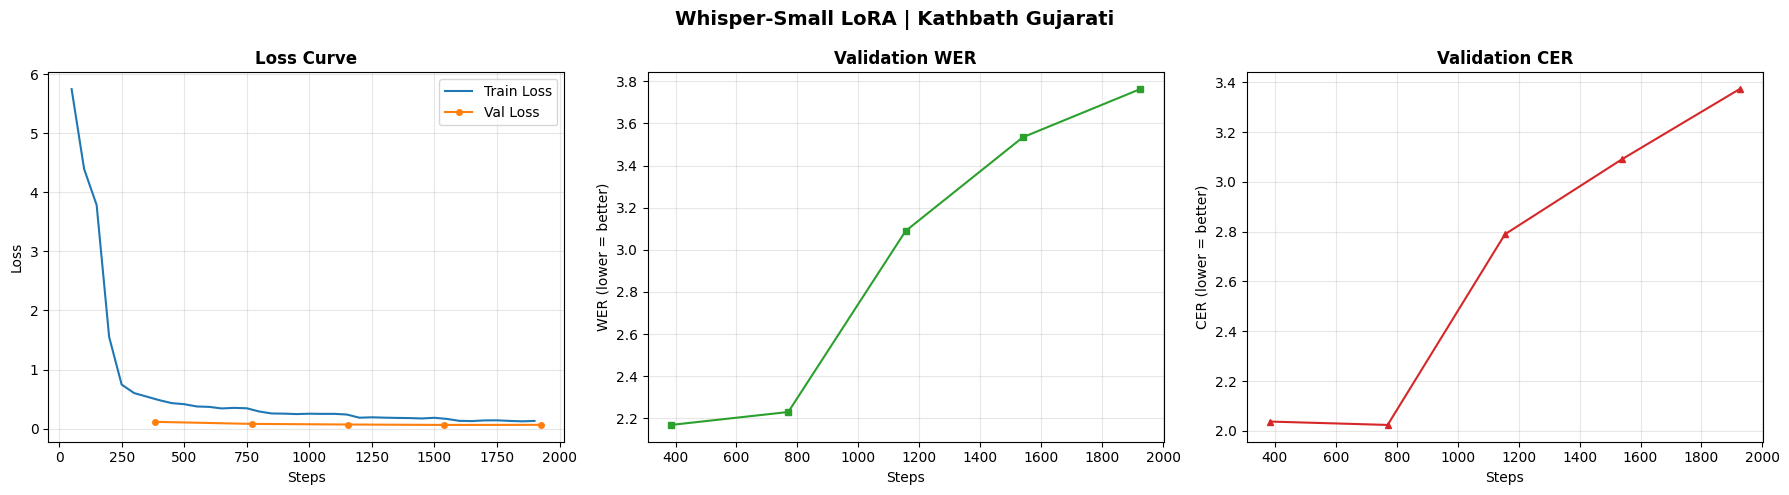

In [60]:
plot_training_curves(trainer.state.log_history, save_dir=hp.output_dir)

In [62]:
def plot_spectrograms(dataset_raw, n=5, text_col="text", save_dir="."):
    indices = random.sample(range(len(dataset_raw)), n)
    fig, axes = plt.subplots(n, 1, figsize=(14, 3 * n))
    if n == 1:
        axes = [axes]
    for ax, idx in zip(axes, indices):
        ex = dataset_raw[idx]
        waveform = np.array(ex[AUDIO_COL]["array"], dtype=np.float32)
        sr = ex[AUDIO_COL]["sampling_rate"]
        text = ex.get(text_col, "")
        S = librosa.feature.melspectrogram(y=waveform, sr=sr, n_mels=80, fmax=8000)
        S_db = librosa.power_to_db(S, ref=np.max)
        img = librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel",
                                        fmax=8000, ax=ax, cmap="magma")
        fig.colorbar(img, ax=ax, format="%+2.0f dB")
        ax.set_title(f"[{idx}] {text[:80]}" , fontsize=9, fontproperties=gujarati_font)
        ax.text(0.01, 0.95, text[:80], transform=ax.transAxes,
        fontproperties=gujarati_font, fontsize=8, va="top")
    plt.suptitle("Mel Spectrograms — Kathbath Gujarati", fontsize=12, fontweight="bold")
    plt.tight_layout()
    fpath = os.path.join(save_dir, "spectrograms.png")
    plt.savefig(fpath, dpi=150)
    wandb.log({"spectrograms": wandb.Image(fpath)})
    plt.show()

/tmp/ipykernel_55/2775170517.py:20: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Gujarati.
  plt.tight_layout()
/tmp/ipykernel_55/2775170517.py:20: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Gujarati.
  plt.tight_layout()
/tmp/ipykernel_55/2775170517.py:22: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Gujarati.
  plt.savefig(fpath, dpi=150)
/tmp/ipykernel_55/2775170517.py:22: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Gujarati.
  plt.savefig(fpath, dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Gujarati.
  dpi = dpi * 2
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Gujarati.
  dpi = dpi * 2


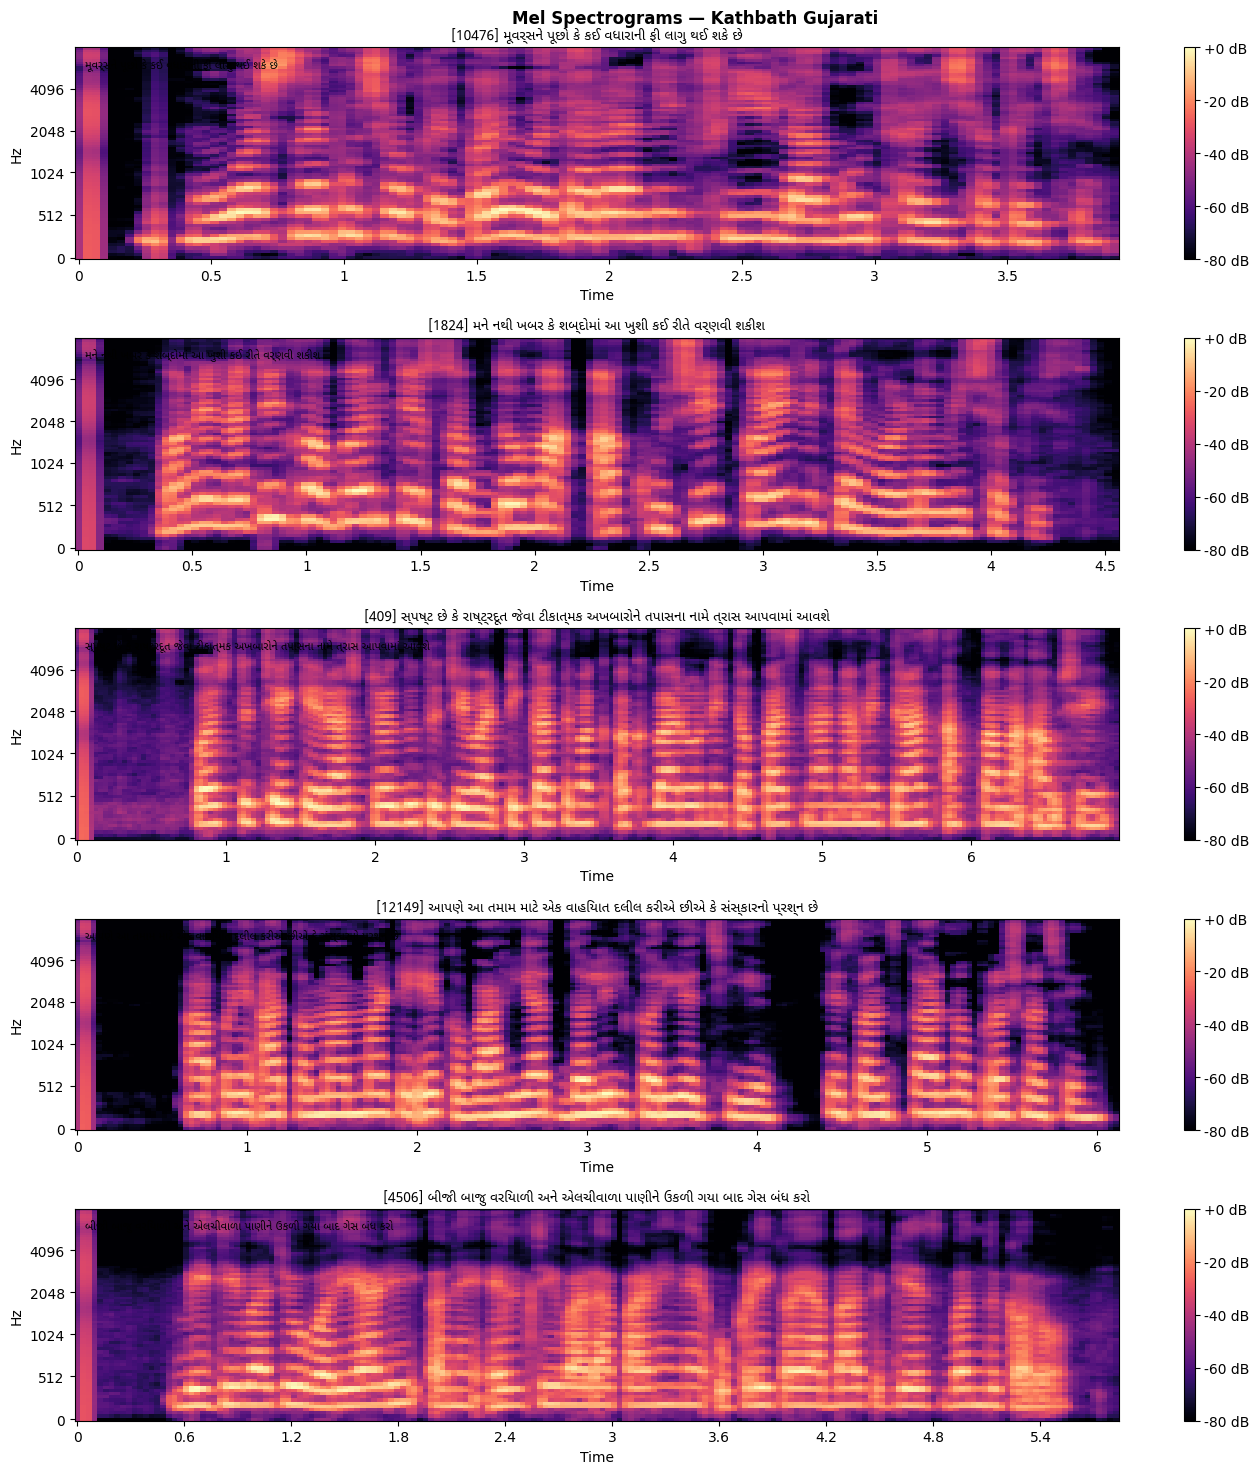

In [ ]:
import matplotlib.font_manager as fm


gujarati_font = fm.FontProperties(fname="/tmp/NotoSansGujarati-Regular.ttf")

plt.rcParams["font.family"] = "DejaVu Sans"

plot_spectrograms(raw["train"], n=5, text_col=TEXT_COL, save_dir=hp.output_dir)

In [64]:
print("---------------Test Eval--------------")
test_results = trainer.evaluate(
    eval_dataset=processed["test"],
    metric_key_prefix="test",
)
trainer.log_metrics("test", test_results)
trainer.save_metrics("test", test_results)
print(test_results)
wandb.log(test_results)

---------------Test Eval--------------


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


early stopping required metric_for_best_model, but did not find eval_wer so early stopping is disabled


***** test metrics *****
  epoch                   =        5.0
  test_cer                =     1.8421
  test_loss               =     0.1173
  test_runtime            = 0:11:40.97
  test_samples_per_second =      2.194
  test_steps_per_second   =      0.138
  test_wer                =     1.9919
{'test_loss': 0.1173095703125, 'test_wer': 1.9919, 'test_cer': 1.8421, 'test_runtime': 700.9716, 'test_samples_per_second': 2.194, 'test_steps_per_second': 0.138, 'epoch': 5.0}


In [65]:
!pip install optimum[onnxruntime]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 885.5 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.2/161.2 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 68.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 59.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.2/194.2 kB 15.8 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
def run_full_inference(model, processor, dataset_raw, dataset_proc, n_samples=None, text_col="sentence"):
    """Run inference on test set and compute detailed metrics."""
    model.eval()
    all_preds, all_refs = [], []

    n = n_samples or len(dataset_proc)
    indices = list(range(min(n, len(dataset_proc))))

    print(f"Running inference on {len(indices)} test samples…")
    batch_size = 8
    for start in range(0, len(indices), batch_size):
        batch_idx = indices[start:start + batch_size]
        batch_features = torch.tensor(
            np.stack([dataset_proc[i]["input_features"] for i in batch_idx]),
            dtype=torch.float16 if hp.fp16 else torch.float32,
        ).to(DEVICE)

        with torch.no_grad():
            pred_ids = model.generate(
                batch_features,
                forced_decoder_ids=processor.get_decoder_prompt_ids(
                    language=hp.language, task=hp.task
                ),
                max_new_tokens=hp.generation_max_length,
            )

        preds = tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
        refs  = [
            normalize_text(dataset_raw[i].get(text_col, ""))
            for i in batch_idx
        ]
        all_preds.extend([normalize_text(p) for p in preds])
        all_refs.extend(refs)

    wer_score = wer_metric.compute(predictions=all_preds, references=all_refs)
    cer_score = cer_metric.compute(predictions=all_preds, references=all_refs)


    results = {
        "test_wer":    round(wer_score, 4),
        "test_cer":    round(cer_score, 4),
    }
    print("\n── Final Test Metrics ──────────────────────────────")
    for k, v in results.items():
        print(f"  {k:20s}: {v:.4f}")

    wandb.log(results)

    print("\n── Sample Predictions ──────────────────────────────")
    for i in range(min(10, len(all_preds))):
        print(f"[{i+1}] REF : {all_refs[i]}")
        print(f"     PRED: {all_preds[i]}")
        print()

    return all_preds, all_refs, results

In [ ]:
best_model = WhisperForConditionalGeneration.from_pretrained(hp.model_name)
best_model.generation_config.forced_decoder_ids = None
best_model.generation_config.suppress_tokens    = []
best_model = PeftModel.from_pretrained(best_model, hp.output_dir)
best_model = best_model.merge_and_unload()   
best_model = best_model.to(DEVICE)
if hp.fp16:
    best_model = best_model.half()

preds, refs, final_metrics = run_full_inference(
    best_model, processor,
    raw["test"], processed["test"],
    text_col=text_col,
)

In [ ]:
BEST_MODEL_DIR = Path(hp.output_dir) / "best_merged"
BEST_MODEL_DIR.mkdir(parents=True, exist_ok=True)

best_model.save_pretrained(str(BEST_MODEL_DIR))
processor.save_pretrained(str(BEST_MODEL_DIR))
tokenizer.save_pretrained(str(BEST_MODEL_DIR))
print("Merged model saved to:", BEST_MODEL_DIR)

In [69]:
torch.save(
    {
        "model_state_dict": best_model.state_dict(),
        "hyperparams": hp.__dict__,
        "final_metrics": final_metrics,
    },
    str(BEST_MODEL_DIR / "checkpoint.pt"),
)
print("PyTorch checkpoint saved.")

PyTorch checkpoint saved.


In [72]:
!pip install -q "optimum==1.17.1" "transformers==4.38.2"

In [ ]:
# from optimum.onnxruntime import ORTModelForSpeechSeq2Seq
# from transformers import pipeline as hf_pipeline

# print("\nExporting to ONNX (optimum)…")
# ONNX_DIR = Path(hp.onnx_dir)
# ONNX_DIR.mkdir(parents=True, exist_ok=True)

# ort_model = ORTModelForSpeechSeq2Seq.from_pretrained(
#     str(BEST_MODEL_DIR),
#     export=True,
#     provider="CPUExecutionProvider",
# )
# ort_model.save_pretrained(str(ONNX_DIR))
# processor.save_pretrained(str(ONNX_DIR))
# print(f"ONNX model saved to: {ONNX_DIR}")

In [ ]:
# onnx_pipe = hf_pipeline(
#     "automatic-speech-recognition",
#     model=ort_model,
#     tokenizer=tokenizer,
#     feature_extractor=feature_extractor,
# )
# sample_audio = raw["test"][0]["audio"]
# onnx_out = onnx_pipe({"sampling_rate": sample_audio["sampling_rate"],
#                         "raw": sample_audio["array"]})
# print("ONNX test output:", onnx_out["text"])
# print("Reference        :", normalize_text(raw["test"][0].get(text_col, "")))

In [90]:
import shutil
import zipfile
from pathlib import Path

def zip_and_download(source_dir: str, zip_name: str):
    zip_path = f"/kaggle/working/{zip_name}"
    print(f"Zipping {source_dir} → {zip_path} …")
    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        for fpath in Path(source_dir).rglob("*"):
            if fpath.is_file():
                zf.write(fpath, arcname=fpath.relative_to(source_dir))
    size_mb = os.path.getsize(zip_path) / 1e6
    print(f"Done. {size_mb:.1f} MB → download from Output tab")



In [91]:
zip_and_download(hp.output_dir,      "whisper_small_gu_lora_adapter.zip")
zip_and_download(str(BEST_MODEL_DIR), "whisper_small_gu_merged.zip")
# zip_and_download(hp.onnx_dir,         "whisper_small_gu_onnx.zip")

Zipping ./whisper-small-gu-lora → /kaggle/working/whisper_small_gu_lora_adapter.zip …
Done. 1374.3 MB → download from Output tab
Zipping whisper-small-gu-lora/best_merged → /kaggle/working/whisper_small_gu_merged.zip …
Done. 892.1 MB → download from Output tab


In [92]:
shutil.copy(
    str(BEST_MODEL_DIR / "checkpoint.pt"),
    "/kaggle/working/checkpoint.pt"
)
print("checkpoint.pt saved → download from Output tab")

checkpoint.pt saved → download from Output tab


In [93]:
artifact = wandb.Artifact("whisper-small-gu-lora", type="model")
artifact.add_dir(hp.output_dir)
run.log_artifact(artifact)
wandb.finish()
print("W&B run finished. All artifacts logged.")

wandb: Adding directory to artifact (whisper-small-gu-lora)... Done. 2.7s


UsageError: Run (suu5s93m) is finished. The call to `log_artifact` will be ignored. Please make sure that you are using an active run.

In [95]:
from huggingface_hub import HfApi

api = HfApi()
api.create_repo("rtxtd/whisper-small-gu-lora", exist_ok=True)
api.upload_folder(
    folder_path=str(BEST_MODEL_DIR),
    repo_id="rtxtd/whisper-small-gu-lora",
    token=hf_token,
)
print("Model pushed to HuggingFace Hub")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


Model pushed to HuggingFace Hub


In [99]:
BEST_MODEL_DIR = Path(hp.output_dir) / "best_merged"
dest = Path("/kaggle/working/model_files")
dest.mkdir(exist_ok=True)
shutil.copytree(str(BEST_MODEL_DIR), str(dest), dirs_exist_ok=True)
print("Files copied — try downloading individually from Output tab")

Files copied — try downloading individually from Output tab
